# Router

In the **router** architecture, a routing step classifies input and directs it to specialized [agents](/oss/python/langchain/agents). This is useful when you have distinct **verticals**—separate knowledge domains that each require their own agent.

![alt text](./agent-router.png)

## Key characteristics

* Router decomposes the query
* Zero or more specialized agents are invoked in parallel
* Results are synthesized into a coherent response

## When to use

Use the router pattern when you have distinct verticals (separate knowledge domains that each require their own agent), need to query multiple sources in parallel, and want to synthesize results into a combined response.

## Basic implementation

The router classifies the query and directs it to the appropriate agent(s). Use `Command` for single-agent routing or `Send` for parallel fan-out to multiple agents.

  - Single agent routing with `Command`

    ```python  
    from langgraph.types import Command

    def classify_query(query: str) -> str:
        """Use LLM to classify query and determine the appropriate agent."""
        # Classification logic here
        ...

    def route_query(state: State) -> Command:
        """Route to the appropriate agent based on query classification."""
        active_agent = classify_query(state["query"])

        # Route to the selected agent
        return Command(goto=active_agent)
    ```

  - Multiple agents (parallel) with `Send` to fan out to multiple specialized agents in parallel:

    ```python  
    from typing import TypedDict
    from langgraph.types import Send

    class ClassificationResult(TypedDict):
        query: str
        agent: str

    def classify_query(query: str) -> list[ClassificationResult]:
        """Use LLM to classify query and determine which agents to invoke."""
        # Classification logic here
        ...

    def route_query(state: State):
        """Route to relevant agents based on query classification."""
        classifications = classify_query(state["query"])

        # Fan out to selected agents in parallel
        return [
            Send(c["agent"], {"query": c["query"]})
            for c in classifications
        ]
    ```

In [1]:
"""
Multi-Source Knowledge Router Example

router pattern with multi-agent systems.
router classifies queries, routes them to specialized agents in parallel,
and synthesizes results into a combined response.
"""

import operator
from typing import Annotated, Literal, TypedDict

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from pydantic import BaseModel, Field


# State definitions
class AgentInput(TypedDict):
    """Simple input state for each subagent."""
    query: str


class AgentOutput(TypedDict):
    """Output from each subagent."""
    source: str
    result: str


class Classification(TypedDict):
    """A single routing decision: which agent to call with what query."""
    source: Literal["github", "notion", "slack"]
    query: str


class RouterState(TypedDict):
    query: str
    classifications: list[Classification]
    results: Annotated[list[AgentOutput], operator.add]
    final_answer: str


# Structured output schema for classifier
class ClassificationResult(BaseModel):
    """Result of classifying a user query into agent-specific sub-questions."""
    classifications: list[Classification] = Field(
        description="List of agents to invoke with their targeted sub-questions"
    )


# Tools
@tool
def search_code(query: str, repo: str = "main") -> str:
    """Search code in GitHub repositories."""
    return f"Found code matching '{query}' in {repo}: authentication middleware in src/auth.py"


@tool
def search_issues(query: str) -> str:
    """Search GitHub issues and pull requests."""
    return f"Found 3 issues matching '{query}': #142 (API auth docs), #89 (OAuth flow), #203 (token refresh)"


@tool
def search_prs(query: str) -> str:
    """Search pull requests for implementation details."""
    return f"PR #156 added JWT authentication, PR #178 updated OAuth scopes"


@tool
def search_notion(query: str) -> str:
    """Search Notion workspace for documentation."""
    return f"Found documentation: 'API Authentication Guide' - covers OAuth2 flow, API keys, and JWT tokens"


@tool
def get_page(page_id: str) -> str:
    """Get a specific Notion page by ID."""
    return f"Page content: Step-by-step authentication setup instructions"


@tool
def search_slack(query: str) -> str:
    """Search Slack messages and threads."""
    return f"Found discussion in #engineering: 'Use Bearer tokens for API auth, see docs for refresh flow'"


@tool
def get_thread(thread_id: str) -> str:
    """Get a specific Slack thread."""
    return f"Thread discusses best practices for API key rotation"


# Models and agents
model = init_chat_model("openai:gpt-4o")
router_llm = init_chat_model("openai:gpt-4o-mini")

github_agent = create_agent(
    model,
    tools=[search_code, search_issues, search_prs],
    system_prompt=(
        "You are a GitHub expert. Answer questions about code, "
        "API references, and implementation details by searching "
        "repositories, issues, and pull requests."
    ),
)

notion_agent = create_agent(
    model,
    tools=[search_notion, get_page],
    system_prompt=(
        "You are a Notion expert. Answer questions about internal "
        "processes, policies, and team documentation by searching "
        "the organization's Notion workspace."
    ),
)

slack_agent = create_agent(
    model,
    tools=[search_slack, get_thread],
    system_prompt=(
        "You are a Slack expert. Answer questions by searching "
        "relevant threads and discussions where team members have "
        "shared knowledge and solutions."
    ),
)


# Workflow nodes
def classify_query(state: RouterState) -> dict:
    """Classify query and determine which agents to invoke."""
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """Analyze this query and determine which knowledge bases to consult.
For each relevant source, generate a targeted sub-question optimized for that source.

Available sources:
- github: Code, API references, implementation details, issues, pull requests
- notion: Internal documentation, processes, policies, team wikis
- slack: Team discussions, informal knowledge sharing, recent conversations

Return ONLY the sources that are relevant to the query."""
        },
        {"role": "user", "content": state["query"]}
    ])

    return {"classifications": result.classifications}


def route_to_agents(state: RouterState) -> list[Send]:
    """Fan out to agents based on classifications."""
    return [
        Send(c["source"], {"query": c["query"]})
        for c in state["classifications"]
    ]


def query_github(state: AgentInput) -> dict:
    """Query the GitHub agent."""
    result = github_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "github", "result": result["messages"][-1].content}]}


def query_notion(state: AgentInput) -> dict:
    """Query the Notion agent."""
    result = notion_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "notion", "result": result["messages"][-1].content}]}


def query_slack(state: AgentInput) -> dict:
    """Query the Slack agent."""
    result = slack_agent.invoke({
        "messages": [{"role": "user", "content": state["query"]}]
    })
    return {"results": [{"source": "slack", "result": result["messages"][-1].content}]}


def synthesize_results(state: RouterState) -> dict:
    """Combine results from all agents into a coherent answer."""
    if not state["results"]:
        return {"final_answer": "No results found from any knowledge source."}

    formatted = [
        f"**From {r['source'].title()}:**\n{r['result']}"
        for r in state["results"]
    ]

    synthesis_response = router_llm.invoke([
        {
            "role": "system",
            "content": f"""Synthesize these search results to answer the original question: "{state['query']}"

- Combine information from multiple sources without redundancy
- Highlight the most relevant and actionable information
- Note any discrepancies between sources
- Keep the response concise and well-organized"""
        },
        {"role": "user", "content": "\n\n".join(formatted)}
    ])

    return {"final_answer": synthesis_response.content}


# Build workflow
workflow = (
    StateGraph(RouterState)
    .add_node("classify", classify_query)
    .add_node("github", query_github)
    .add_node("notion", query_notion)
    .add_node("slack", query_slack)
    .add_node("synthesize", synthesize_results)
    .add_edge(START, "classify")
    .add_conditional_edges("classify", route_to_agents, ["github", "notion", "slack"])
    .add_edge("github", "synthesize")
    .add_edge("notion", "synthesize")
    .add_edge("slack", "synthesize")
    .add_edge("synthesize", END)
    .compile()
)


if __name__ == "__main__":
    result = workflow.invoke({
        "query": "How do I authenticate API requests?"
    })

    print("Original query:", result["query"])
    print("\nClassifications:")
    for c in result["classifications"]:
        print(f"  {c['source']}: {c['query']}")
    print("\n" + "=" * 60 + "\n")
    print("Agents output:")
    for msg in result["results"]:
        display(msg)
    print("\n" + "=" * 60 + "\n")
    print("Final Answer:")
    print(result["final_answer"])


Original query: How do I authenticate API requests?

Classifications:
  github: What are the recommended practices for authenticating API requests in our codebase?
  notion: What is the internal policy for API request authentication?
  slack: Can anyone share experiences or tips on authenticating API requests?


Agents output:


{'source': 'github',
 'result': 'In your codebase, the file `src/auth.py` appears to include authentication middleware, which likely contains the recommended practices for authenticating API requests. Here are some general best practices for API authentication:\n\n1. **Use Secure Protocols**: Ensure communication with APIs happens over HTTPS. This encrypts data in transit, protecting it from interception.\n\n2. **Token-Based Authentication**: Implement token-based authentication, such as JWT (JSON Web Tokens) for stateless sessions. Tokens contain enough data to identify a user or allow certain actions.\n\n3. **API Keys**: If using API keys, treat them like passwords. Keep them secure and rotate them regularly.\n\n4. **OAuth**: For applications requiring access to user data on behalf of users, implement OAuth 2.0, which delegates authorization.\n\n5. **Rate Limiting**: Include rate limiting to prevent abuse and service exhaustion. This also helps identify and block malicious IPs.\n\n6.

{'source': 'notion',
 'result': 'The internal policy for API request authentication is detailed in the "API Authentication Guide." It covers several methods, including OAuth2 flow, API keys, and JWT tokens, with step-by-step instructions for setting up each type of authentication.'}

{'source': 'slack',
 'result': "In a Slack discussion from the #engineering channel, some key points about authenticating API requests were shared:\n\n1. **Bearer Tokens**: It's recommended to use Bearer tokens for API authentication. These are often preferred due to their simplicity and security features. They should be included in the HTTP headers of your request.\n\n2. **Refresh Flow**: Make sure to implement a refresh token flow. This means that when the access token expires, you should be able to use a refresh token to request a new access token without requiring the user to log in again.\n\n3. **Key Rotation**: Regularly rotating API keys or tokens is essential. This means changing your tokens on a periodic basis to enhance security. It's important to plan for how you'll update these keys across all your applications and services to prevent disruptions.\n\nThese practices help maintain secure connections and protect sensitive data during API interactions. If you have further ques



Final Answer:
To authenticate API requests effectively, follow these recommended practices that combine insights from various sources:

### General Best Practices

1. **Use Secure Protocols**: Always communicate with APIs over **HTTPS** to encrypt data in transit.

2. **Token-Based Authentication**:
   - Implement **JWT (JSON Web Tokens)** for stateless sessions, which can carry user identification and authorization data.
   - Utilize **Bearer Tokens** in HTTP headers for simplicity and security.

3. **API Keys**: Treat API keys like passwords:
   - Keep them secure and **rotate them regularly**.
   - Store sensitive keys in **environment variables** instead of hardcoding them in your source code.

4. **OAuth 2.0**: For applications needing to access user data, implement **OAuth 2.0** to delegate authorization securely.

5. **Refresh Token Flow**: Ensure a mechanism is in place to refresh access tokens using refresh tokens without requiring user re-login.

6. **Rate Limiting**: Imple

'workflow'

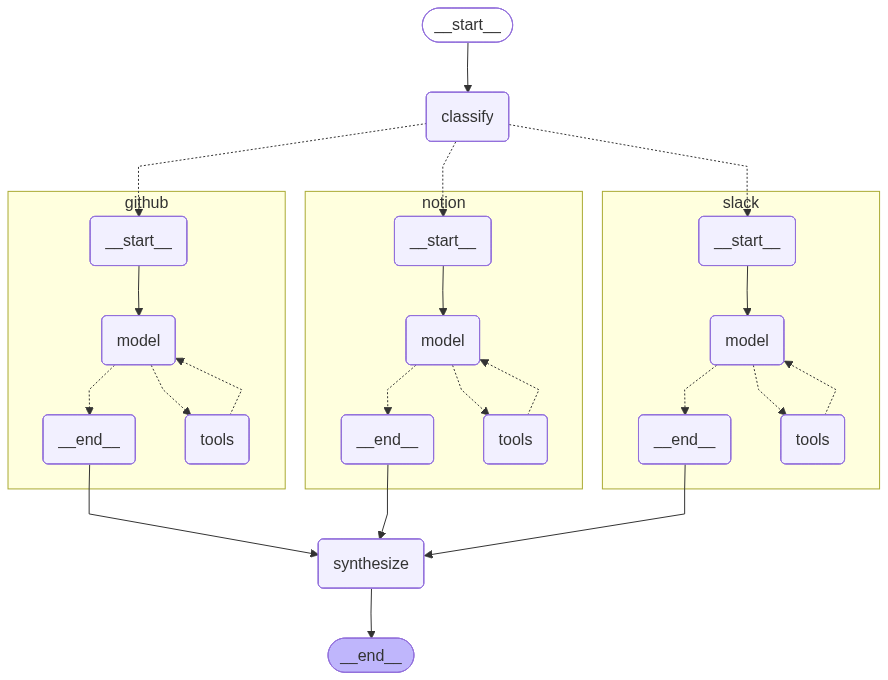

In [2]:
from IPython.display import display, Image
display("workflow",Image(workflow.get_graph(xray=True).draw_mermaid_png()))   

## Stateless vs. stateful

Two approaches:

* [**Stateless routers**](#stateless) address each request independently
* [**Stateful routers**](#stateful) maintain conversation history across requests

## Stateless

Each request is routed independently — no memory between calls. 

<Tip>

  **Router vs. Subagents**: Both patterns can dispatch work to multiple agents, but they differ in how routing decisions are made:

  * **Router**: A dedicated routing step (often a single LLM call or rule-based logic) that classifies the input and dispatches to agents. The router itself typically doesn't maintain conversation history or perform multi-turn orchestration — it's a _preprocessing_ step.
  * **Subagents**: An main supervisor agent dynamically decides which `subagents` to call as part of an ongoing conversation. The main agent maintains context, can call multiple subagents across turns, and orchestrates complex multi-step workflows.

  Use a **router** when you have clear input categories and want deterministic or lightweight classification. Use a **supervisor** when you need flexible, conversation-aware orchestration where the LLM decides what to do next based on evolving context.
</Tip>

## Stateful

For multi-turn conversations, you need to maintain context across invocations.

### Tool wrapper

The simplest approach: wrap the stateless router as a tool that a conversational agent can call. The conversational agent handles memory and context; the router stays stateless. This avoids the complexity of managing conversation history across multiple parallel agents.

In [7]:
@tool
def search_docs(query: str) -> str:
    """Search across multiple documentation sources."""
    result = workflow.invoke({"query": query})  
    return result["final_answer"]

# Conversational agent uses the router as a tool
conversational_agent = create_agent(
    model,
    tools=[search_docs],
    system_prompt="You are a helpful assistant. Use search_docs to answer questions."
)

query = "How do I authenticate API requests?"
response = conversational_agent.invoke({"messages": [{"role": "user", "content": query}]})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

How do I authenticate API requests?
================================== Ai Message ==================================
Tool Calls:
  search_docs (call_ZpulVz3qbBZWP7m0PNuA77sV)
 Call ID: call_ZpulVz3qbBZWP7m0PNuA77sV
  Args:
    query: API request authentication methods
================================= Tool Message =================================
Name: search_docs

When it comes to API request authentication methods, several common practices are generally adopted across platforms. Below is a synthesis of key methods based on the information gathered:

1. **OAuth2**:
   - Widely used for third-party applications to access user data securely without sharing login credentials. 
   - Involves a multi-step flow that includes obtaining a client ID, a client secret, authorizing the application, exchanging authorization codes, and refreshing access tokens. 

   *Actionable Tip*: Refer to comprehensive guides or 